In [86]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [87]:
dt=pd.read_csv("IRIS.csv")

In [88]:
dt.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
from sklearn.preprocessing import LabelEncoder
dt=dt.dropna()

In [90]:
binary=LabelEncoder()
dt['species']=binary.fit_transform(dt['species'])


In [91]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier

def plot_classifiers(models, X, y, voting='soft'):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Fit each model
    fitted_models = []
    for name, model in models:
        model.fit(X_train, y_train)
        fitted_models.append((name, model))

    # Voting classifier
    voting_clf = VotingClassifier(estimators=fitted_models, voting=voting)
    voting_clf.fit(X_train, y_train)

    # Create grid for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # Plot each model and voting classifier
    n_models = len(fitted_models) + 1
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))

    if n_models == 1:
        axes = [axes]  # Handle single model

    for ax, (name, model) in zip(axes[:-1], fitted_models):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=30)
        ax.set_title(name)
        acc=model.score(X_test,y_test)
        ax.set_title(f"{name}\nAcc={acc:.2f}")

    # Voting classifier plot
    Z = voting_clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[-1].contourf(xx, yy, Z, alpha=0.3)
    axes[-1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=30)
    acc = voting_clf.score(X_test, y_test)
    axes[-1].set_title(f"VotingClassifier\nAcc={acc:.2f}")

    plt.tight_layout()
    plt.show()


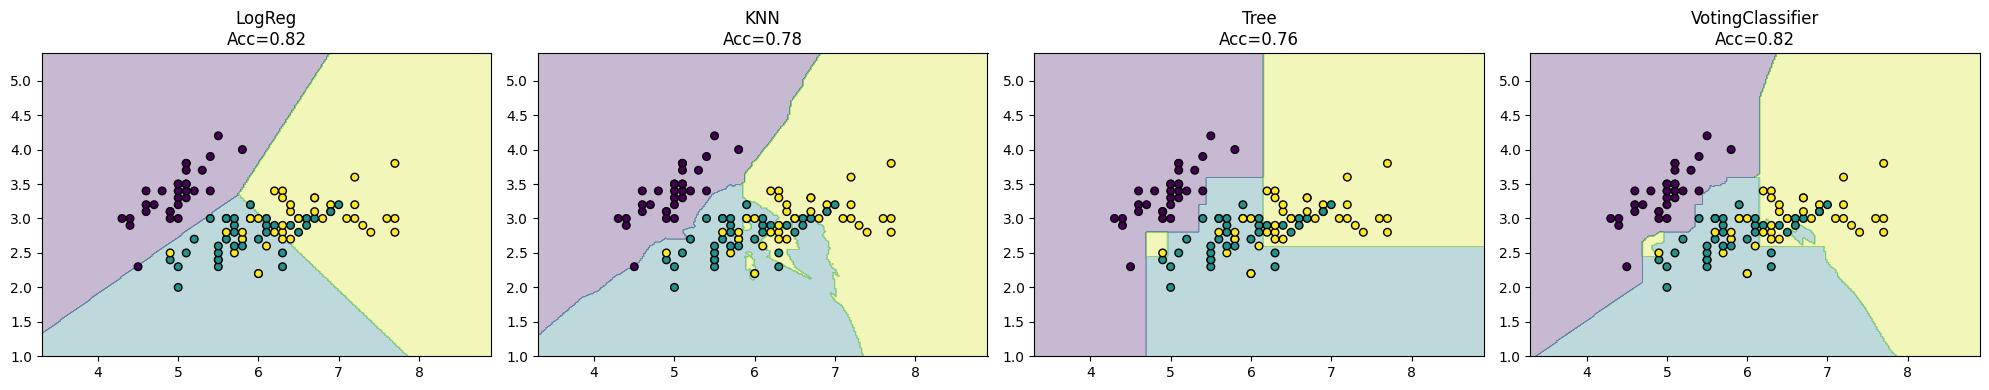

In [93]:
if __name__ == "__main__":
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    X=dt.iloc[:,0:2].values
    y=dt.iloc[:,-1].values

    classifiers = [
        ("LogReg", LogisticRegression()),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        ("Tree", DecisionTreeClassifier(max_depth=5))
    ]

    plot_classifiers(classifiers, X, y, voting='soft')